<a href="https://colab.research.google.com/github/JonathanDLCH/Crypto_DataAnalysis/blob/main/Stock_Market_API_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 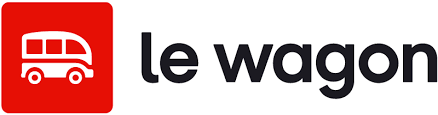

# Stock Market API

En este ejercicio vamos a trabajar con la API del mercado de valores [Massive](https://massive.com/) (anteriormente conocida como Polygon.io).

El objetivo es familiarizarse con la lectura de documentación de APIs.

Localicemos la página de documentación de la API de [Massive](https://massive.com/)

<details><summary markdown='span'>Solución
</summary>
Las páginas de documentación suelen estar ocultas en el footer o en un menú.<br/>
Escribir <i>'nombre_del_sitio API documentation'</i> en la barra de búsqueda de Google es una forma rápida de encontrarla
<br>
Solución: <a href="https://massive.com/docs/rest/stocks/overview">https://massive.com/docs/rest/stocks/overview</a>
</details>

---

## Configuración de la API

Los endpoints de la API que queremos usar están protegidos por una clave API (API key). Puedes crear una gratis [aquí](https://massive.com/dashboard/signup).

Puedes probarla ahora editando este enlace con tu API key:

```
https://api.massive.com/v2/aggs/ticker/META/range/1/week/2024-01-01/2024-12-31?apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c
```

---

## Usando la API

Ahora, encontremos en la API de Massive la **URL** para obtener los precios mensuales de las acciones de META.

Cuando encuentres la URL, cópiala y pégala en una nueva pestaña del navegador para ver los datos de la API.
Debería ser un JSON, similar al siguiente ejemplo:

<details><summary markdown='span'>Mostrar ejemplo
</summary>

```json
{
    "ticker": "META",
    "adjusted": true,
    "queryCount": 12,
    "resultsCount": 12,
    "status": "OK",
    "results": [
        {
            "c": 474.99,
            "h": 531.49,
            "l": 468.00,
            "n": 9528405,
            "o": 469.00,
            "t": 1704067200000,
            "v": 392854293,
            "vw": 494.3291
        },
        {
            "c": 487.05,
            "h": 502.60,
            "l": 451.55,
            "o": 477.00,
            "t": 1706745600000,
            "v": 421567890,
            "vw": 476.8823
        }
    ]
}
```

**Campos de respuesta:**
- `c`: Precio de cierre (close)
- `o`: Precio de apertura (open)
- `h`: Precio más alto (high)
- `l`: Precio más bajo (low)
- `v`: Volumen de transacciones
- `t`: Timestamp Unix en milisegundos
- `vw`: Precio promedio ponderado por volumen
</details>

⚠️ Tómate tu tiempo antes de leer la solución. Encontrar información en la documentación de una API típicamente requiere **10 a 15 minutos de lectura**

<details><summary markdown='span'>Solución
</summary>
Puedes encontrar esta información aquí en la documentación:
<a href="https://massive.com/docs/rest/stocks/aggregates/custom-bars">https://massive.com/docs/rest/stocks/aggregates/custom-bars</a>
<br>
La URL es:
<pre>
https://api.massive.com/v2/aggs/ticker/META/range/1/month/2024-01-01/2024-12-31?apiKey=TU_API_KEY
</pre>
</details>

---

## Usando datos de la API en pandas

### Configuración

Comienza con los imports usuales en la primera celda:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
# @title
# TODO: Replace with your API key
API_KEY = "QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c"

Reutilizaremos la **URL de la API** para los **precios mensuales de las acciones de Apple**.

Para hacer una **llamada** a la API puedes usar el siguiente código:

In [3]:
url = f"https://api.massive.com/v2/aggs/ticker/AAPL/range/1/month/2024-01-01/2024-12-31?apiKey={API_KEY}"
api_data = requests.get(url).json()

# Display the response
api_data

{'ticker': 'AAPL',
 'queryCount': 211,
 'resultsCount': 10,
 'adjusted': True,
 'results': [{'v': 1433151760.0,
   'vw': 172.678,
   'o': 179.55,
   'c': 171.48,
   'h': 180.53,
   'l': 168.49,
   't': 1709269200000,
   'n': 16423301},
  {'v': 1246221542.0,
   'vw': 170.3364,
   'o': 171.19,
   'c': 170.33,
   'h': 178.36,
   'l': 164.075,
   't': 1711944000000,
   'n': 14523470},
  {'v': 1336570142.0,
   'vw': 185.8198,
   'o': 169.58,
   'c': 192.25,
   'h': 193,
   'l': 169.11,
   't': 1714536000000,
   'n': 14476564},
  {'v': 1723984420.0,
   'vw': 207.9435,
   'o': 192.9,
   'c': 210.62,
   'h': 220.2,
   'l': 192.15,
   't': 1717214400000,
   'n': 16908402},
  {'v': 1153193377.0,
   'vw': 224.7261,
   'o': 212.09,
   'c': 222.08,
   'h': 237.23,
   'l': 211.92,
   't': 1719806400000,
   'n': 15620462},
  {'v': 1122666993.0,
   'vw': 220.0061,
   'o': 224.37,
   'c': 229,
   'h': 232.92,
   'l': 196,
   't': 1722484800000,
   'n': 15120557},
  {'v': 1232391861.0,
   'vw': 224.6517

Ahora puedes **crear un dataframe** a partir de estos datos.

<details><summary markdown='span'>Solución
</summary>
<code>apple_stock_df = pd.DataFrame(api_data['results'])</code>
</details>

In [4]:
# TODO: Create a DataFrame from api_data['results']

df_AAPL = pd.DataFrame(api_data['results'])

Con este dataframe podemos **graficar** la evolución del precio de las acciones.
Pero antes de eso necesitamos hacer algunas cosas:
- Convertir el timestamp Unix (milisegundos) a un objeto datetime
- Establecer la columna de fecha como índice
- Renombrar las columnas para mayor claridad

### Convertir timestamp a datetime

La columna `t` contiene timestamps Unix en milisegundos. Para convertirlos a datetime puedes usar `pd.to_datetime()` con el parámetro `unit='ms'`.

- **pd.to_datetime** documentación: [https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)

<details><summary markdown='span'>Solución
</summary>
<code>apple_stock_df['date'] = pd.to_datetime(apple_stock_df['t'], unit='ms')</code>
</details>

In [5]:
# TODO: Convert timestamp column 't' to datetime
df_AAPL['datetime'] = pd.to_datetime(df_AAPL['t'], unit='ms')

df_AAPL.head()


,v,vw,o,c,h,l,t,n,datetime
0,1.433152e+09,172.6780,179.55,171.48,180.53,168.490,1709269200000,16423301,2024-03-01 05:00:00
1,1.246222e+09,170.3364,171.19,170.33,178.36,164.075,1711944000000,14523470,2024-04-01 04:00:00
2,1.336570e+09,185.8198,169.58,192.25,193.00,169.110,1714536000000,14476564,2024-05-01 04:00:00
3,1.723984e+09,207.9435,192.90,210.62,220.20,192.150,1717214400000,16908402,2024-06-01 04:00:00
4,1.153193e+09,224.7261,212.09,222.08,237.23,211.920,1719806400000,15620462,2024-07-01 04:00:00


### Establecer la columna de fecha como índice

Para hacer esto puedes usar el método **set_index** del DataFrame

- documentación: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html)

<details><summary markdown='span'>Solución
</summary>
<code>apple_stock_df = apple_stock_df.set_index('date')</code>
</details>

In [6]:
# TODO: Set the date column as the index
df_AAPL = df_AAPL.set_index('datetime')
df_AAPL.head()

,v,vw,o,c,h,l,t,n
datetime,,,,,,,,
2024-03-01 05:00:00,1.433152e+09,172.6780,179.55,171.48,180.53,168.490,1709269200000,16423301
2024-04-01 04:00:00,1.246222e+09,170.3364,171.19,170.33,178.36,164.075,1711944000000,14523470
2024-05-01 04:00:00,1.336570e+09,185.8198,169.58,192.25,193.00,169.110,1714536000000,14476564
2024-06-01 04:00:00,1.723984e+09,207.9435,192.90,210.62,220.20,192.150,1717214400000,16908402
2024-07-01 04:00:00,1.153193e+09,224.7261,212.09,222.08,237.23,211.920,1719806400000,15620462


### Renombrar columnas

Los nombres de columnas de la API de Massive son abreviaciones. Vamos a renombrarlas para mayor claridad:
- `c` → `close`
- `o` → `open`
- `h` → `high`
- `l` → `low`
- `v` → `volume`

Puedes usar el método **rename** con un diccionario.

<details><summary markdown='span'>Solución
</summary>
<code>apple_stock_df = apple_stock_df.rename(columns={'c': 'close', 'o': 'open', 'h': 'high', 'l': 'low', 'v': 'volume'})</code>
</details>

In [7]:
# TODO: Rename columns for clarity
df_AAPL = df_AAPL.rename(columns={'c': 'close', 'o': 'open', 'h': 'high', 'l': 'low', 'v': 'volume'})
df_AAPL.head()

,volume,vw,open,close,high,low,t,n
datetime,,,,,,,,
2024-03-01 05:00:00,1.433152e+09,172.6780,179.55,171.48,180.53,168.490,1709269200000,16423301
2024-04-01 04:00:00,1.246222e+09,170.3364,171.19,170.33,178.36,164.075,1711944000000,14523470
2024-05-01 04:00:00,1.336570e+09,185.8198,169.58,192.25,193.00,169.110,1714536000000,14476564
2024-06-01 04:00:00,1.723984e+09,207.9435,192.90,210.62,220.20,192.150,1717214400000,16908402
2024-07-01 04:00:00,1.153193e+09,224.7261,212.09,222.08,237.23,211.920,1719806400000,15620462


### ¡Ahora podemos graficar! 🎉

Primero grafiquemos solo los valores en la columna **'close'**

<details><summary markdown='span'>Solución
</summary>
<code>apple_stock_df['close'].plot()</code>
</details>

<Axes: xlabel='datetime'>

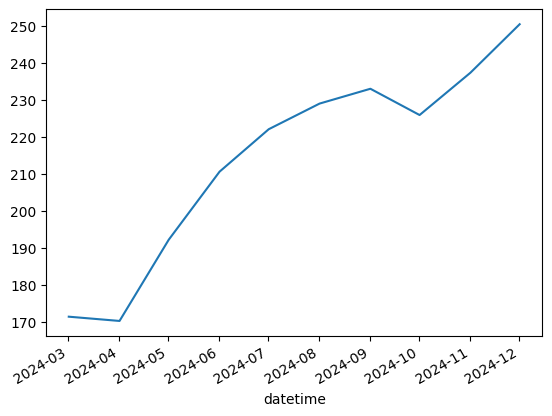

In [8]:
# TODO: Plot the 'close' column
df_AAPL['close'].plot()

Ahora podemos hacer un gráfico con los valores de **'open', 'close', 'high', 'low'**

<details><summary markdown='span'>Solución
</summary>
<code>apple_stock_df[['open', 'high', 'low', 'close']].plot()</code>
</details>

<Axes: xlabel='datetime'>

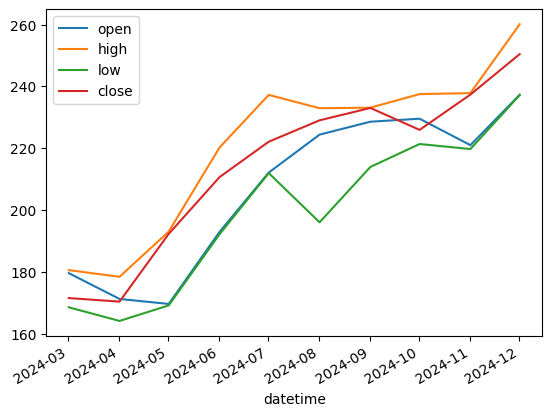

In [9]:
# TODO: Plot open, high, low, close columns
df_AAPL[['open', 'high', 'low', 'close']].plot()

Como podemos ver, nuestro gráfico es difícil de leer. Podemos mejorar su legibilidad con el argumento **figsize** del método `plot()`.
- documentación: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)

<details><summary markdown='span'>Solución
</summary>
<code>apple_stock_df[['open', 'high', 'low', 'close']].plot(figsize=(14, 8))</code>
</details>

<Axes: xlabel='datetime'>

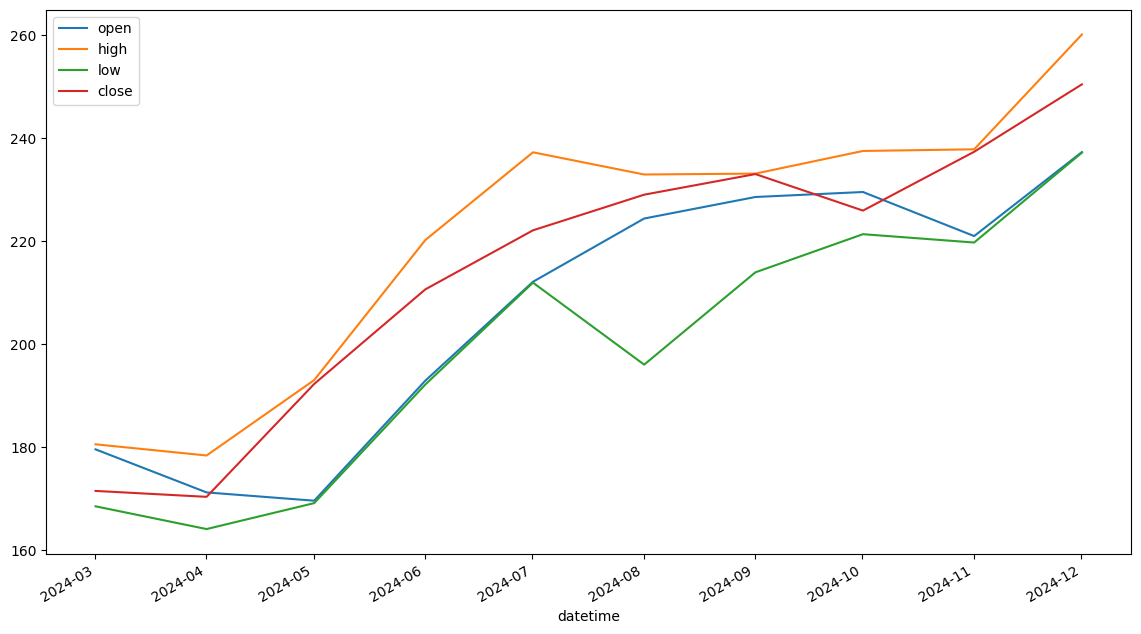

In [10]:
# TODO: Plot with figsize for better readability
df_AAPL[['open', 'high', 'low', 'close']].plot(figsize=(14, 8))

---

## De vuelta a la API

Descubramos qué tipo de datos podemos obtener de esta API 🕵️‍♂️

### ¿Cuál es la URL para:

1) Precios semanales de las acciones de GOOGLE? https://api.massive.com/v2/aggs/ticker/GOOGL/range/1/week/2026-01-01/2026-12-31?apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c
2) Precio diario de apertura/cierre de Meta en una fecha específica? https://api.massive.com/v1/open-close/META/2026-02-20?adjusted=true&apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c
3) Precios mensuales de Amazon del último año? https://api.massive.com/v2/aggs/ticker/AMZN/range/1/month/2026-01-01/2026-12-31?apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c

**Procura encontrar la respuesta a estas preguntas leyendo en la documentacion de Massive antes de revisar las respuestas**

<details><summary markdown='span'>Todas las Soluciones
</summary>
<ol>
    <li>https://api.massive.com/v2/aggs/ticker/GOOGL/range/1/week/2024-01-01/2024-12-31?apiKey=API_KEY</li>
    <li>https://api.massive.com/v1/open-close/META/2024-06-15?apiKey=API_KEY</li>
    <li>https://api.massive.com/v2/aggs/ticker/AMZN/range/1/month/2025-01-01/2025-12-31?apiKey=API_KEY</li>
</ol>
</details>

---

## Conclusión

¡Felicidades! Has completado tu introducción al uso de APIs de mercado de valores. En este notebook aprendiste:

- **¿Qué es una API?** - Una interfaz que permite a tu código comunicarse con servicios externos
- **Documentación de APIs** - Cómo encontrar y leer documentación para entender los endpoints disponibles
- **Autenticación** - Cómo usar API keys para acceder a datos protegidos
- **Requests en Python** - Cómo hacer llamadas a APIs usando la librería `requests`
- **JSON a DataFrame** - Cómo convertir respuestas JSON en DataFrames de pandas
- **Preparación de datos** - Conversión de timestamps, renombrado de columnas e indexación
- **Visualización** - Cómo crear gráficos de precios de acciones con matplotlib

Las APIs son una herramienta fundamental en ciencia de datos, permitiéndote acceder a datos en tiempo real de múltiples fuentes.